# Hotel Booking Cancellation — Predictive Modelling (v4, multi-model comparison + full hyper-parameter tuning)

**Goal:** estimate the probability that a booking will be cancelled *using only information available when the booking is made*,
so the hotel can prioritise follow-ups and quantify revenue at risk. Binary classification (`1 = cancelled`).

### What was wrong in the previous revision (and what this notebook does about it)

| # | Problem found | Effect | Fix in this notebook |
|---|---|---|---|
| 1 | Model comparison / threshold tuning used **shuffled `StratifiedKFold`** on time-ordered data that also contains ~34k duplicate booking rows | Train "OOF" Accuracy 87.1 % vs 79.8 % on the real hold-out → optimistic, and the 0.59 threshold picked on it was too high (Accuracy at 0.5 on test was *higher*, 80.5 %) | **Forward-chaining temporal CV** inside `train_df` |
| 2 | `TimeSeriesSplit` was applied to **rows in file order**, but the file is sorted by *hotel*, not by date (`is_monotonic_increasing == False`) | The "time-respecting" hyper-parameter search was really validating City Hotel rows on Resort Hotel rows | Train/test frames are sorted by `arrival_date` before any CV |
| 3 | `required_car_parking_spaces` kept as a feature although the EDA notebook found **0 % cancellations in all 7,416 bookings with parking** | Classic post-booking leakage (a cancelled guest never checks in, so no parking is ever recorded) — it was the #5 driver on the dashboard | Dropped; a sensitivity run shows what it would have added |
| 4 | LightGBM / CatBoost / Stacking sections were **markdown-only or commented-out**, yet the text and the summary table described them as compared | Misleading documentation | LightGBM is really run and compared; CatBoost is not claimed |
| 5 | Markdown claimed *"Baseline PR-AUC = 0.370"*, executed output was 0.358; several other stale numbers | Text ≠ results | Interpretations are generated from the executed variables |
| 6 | `scale_pos_weight` inflates predicted probabilities, but the dashboard shows them as "risk %" | Risk % was systematically too high (waiting-list "avg risk 65 %") | **Platt calibration** on out-of-time predictions |
| 7 | `FrequencyEncoder` lived in `__main__` → `preprocessor.joblib` could not be loaded outside the notebook; no `get_feature_names_out` → no feature names | Broke reuse in apps / dashboards | Class moved to `hotel_utils.py`, names supported |
| 8 | No same-day *batch* signal (groups of identical bookings cancel together: 54.2 % vs 26.6 %) | Left accuracy on the table | Two booking-time features: `sibling_count`, `agent_day_lead_count` |
| 9 | Sections 09–13 numbering / “Evaluation Strategy” said *Accuracy is not primary* while `SELECTION_METRIC="Accuracy"` | Contradiction | Accuracy is the primary metric **by request**, recall/F1/AUC are always reported next to it |

## 1. Evaluation strategy

* **Primary metric: Accuracy** (requested), always reported together with Precision, Recall, F1, ROC-AUC and PR-AUC — the target is imbalanced (~37 % cancelled), so accuracy alone can hide missed cancellations.
* **Split:** one chronological 80/20 split (`train_df` / `test_df`). `test_df` is used **once**, at the end.
* **Model & threshold selection:** expanding-window temporal cross-validation *inside* `train_df` (train on the past, validate on the next ~3 months).
* Probabilities are **calibrated** so that “risk %” can be read as a probability.

In [1]:
import os, json, time, random, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib, sklearn, xgboost, lightgbm, catboost
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, GroupKFold, TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
warnings.filterwarnings("ignore")

# hotel_utils.py is shipped next to this notebook; it is (re)written here if missing so the notebook is self-contained
UTILS_SRC = '"""Shared helpers for the hotel-cancellation project.\n\nKeeping these classes in a real module (instead of defining them inside the notebook)\nmeans `joblib.load("preprocessor.joblib")` works in ANY script / app / dashboard backend.\nA class that was defined in a notebook is pickled as `__main__.FrequencyEncoder`, which\ncannot be un-pickled anywhere else -- that is why the previous preprocessor.joblib could\nnot be loaded outside the notebook.\n"""\nimport numpy as np\nimport pandas as pd\nfrom sklearn.base import BaseEstimator, TransformerMixin\n\n\nclass FrequencyEncoder(BaseEstimator, TransformerMixin):\n    """Replace each category by its relative frequency learned on the fit data.\n    Never looks at the target, so it cannot leak the label. Unseen -> 0.0."""\n\n    def fit(self, X, y=None):\n        X = pd.DataFrame(X)\n        self.columns_ = [str(c) for c in X.columns]\n        self.freq_maps_ = [X[c].value_counts(normalize=True).to_dict() for c in X.columns]\n        return self\n\n    def transform(self, X):\n        X = pd.DataFrame(X).copy()\n        for i, c in enumerate(X.columns):\n            X[c] = X[c].map(self.freq_maps_[i]).fillna(0.0)\n        return X.values.astype("float64")\n\n    def get_feature_names_out(self, input_features=None):\n        return np.asarray(input_features if input_features is not None else self.columns_, dtype=object)\n\n\nMONTHS = ["January", "February", "March", "April", "May", "June", "July", "August",\n          "September", "October", "November", "December"]\nMONTH_MAP = {m: i + 1 for i, m in enumerate(MONTHS)}\n\n# columns that are removed before modelling (identifiers of the target / post-booking info / redundant copies)\nDROP_ALWAYS = ["is_canceled", "arrival_date", "arrival_date_month", "arrival_date_week_number",\n               "total_guests", "total_nights", "estimated_revenue", "requires_parking",\n               "has_special_requests", "has_previous_cancellation"]\n# booking-time-unknown fields (recorded at / after check-in)\nLEAKAGE_COLS = ["assigned_room_type", "booking_changes", "has_booking_changes", "room_type_changed",\n                "required_car_parking_spaces"]\n'
if not Path("hotel_utils.py").exists():
    Path("hotel_utils.py").write_text(UTILS_SRC)
from hotel_utils import FrequencyEncoder, MONTH_MAP, DROP_ALWAYS, LEAKAGE_COLS

RANDOM_STATE = 42
N_JOBS = os.cpu_count() or 1
SELECTION_METRIC = "Accuracy"          # primary metric (by request); other metrics are always shown
OUT_DIR = Path("models"); OUT_DIR.mkdir(exist_ok=True)
print("sklearn", sklearn.__version__, "| xgboost", xgboost.__version__, "| lightgbm", lightgbm.__version__,
      "| catboost", catboost.__version__, "| pandas", pd.__version__)

sklearn 1.6.1 | xgboost 3.2.0 | lightgbm 4.6.0 | catboost 1.2.10 | pandas 2.3.3


In [2]:
CANDIDATES = [os.environ.get("HOTEL_DATA", ""), "hotel_bookings_final.csv",
              "/kaggle/input/datasets/nadamohamed25/hotel-bokking/hotel_bookings_final.csv"]
DATA_PATH = next(p for p in CANDIDATES if p and Path(p).exists())
data = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH, "| shape:", data.shape)
data.head(3)

Loaded: /kaggle/input/datasets/nadamohamed25/hotel-bokking/hotel_bookings_final.csv | shape: (119389, 44)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,total_guests,estimated_revenue,party_size_category,stay_type,lead_time_category,has_booking_changes,has_previous_cancellation,has_special_requests,requires_parking,room_type_changed
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,2,0.0,Small,No Stay,Very Long Term,1,0,0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,2,0.0,Small,No Stay,Very Long Term,1,0,0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,1,75.0,Solo,Weekday Only,Last Minute,0,0,0,0,1


In [3]:
TARGET = "is_canceled"
vc = data[TARGET].value_counts().sort_index()
print(pd.DataFrame({"Count": vc, "Percentage": (vc / len(data) * 100).round(2)}).rename(index={0: "Not cancelled", 1: "Cancelled"}))

               Count  Percentage
is_canceled                     
Not cancelled  75165       62.96
Cancelled      44224       37.04


## 2. Leakage review

The EDA notebook already removed `reservation_status` / `reservation_status_date`. In this dataset three more fields describe what happened **after** the booking was made (`assigned_room_type`, `booking_changes`, and derived flags), so they are removed too.

`required_car_parking_spaces` needs an explicit check: the EDA notebook found a *perfect* 0 % cancellation rate for it and asked the modelling team to confirm that it is booking-time information.

In [4]:
park = data[data["required_car_parking_spaces"] > 0]
print(f"Bookings with parking > 0 : {len(park):,}")
print(f"  of which cancelled      : {int(park[TARGET].sum())}  ({park[TARGET].mean():.1%})")
print(f"Cancelled bookings with parking > 0 : {int(((data[TARGET]==1) & (data['required_car_parking_spaces']>0)).sum())}")
print(f"Overall cancellation rate: {data[TARGET].mean():.1%}")

Bookings with parking > 0 : 7,416
  of which cancelled      : 0  (0.0%)
Cancelled bookings with parking > 0 : 0
Overall cancellation rate: 37.0%


**Decision.** Among 37 % cancellations, *not one* has a parking space. A guest who requests parking at booking time can still cancel, so a rate of exactly 0 % means the field is only filled in for guests who actually arrive — i.e. it encodes the outcome. `required_car_parking_spaces` (and `requires_parking`) are therefore treated as **leakage** and excluded, like `assigned_room_type` and `booking_changes`.

In [5]:
ml_df = data.drop(columns=[c for c in LEAKAGE_COLS if c in data.columns]).copy()
print("Dropped as post-booking information:", [c for c in LEAKAGE_COLS if c in data.columns])
print("ML dataset shape:", ml_df.shape)

# Duplicates: the EDA notebook reported 0 because its synthetic PII columns (name/email/...) were unique per row.
# After PII removal the real picture appears:
dup_mask = ml_df.duplicated(keep="first")
print(f"\nDuplicated booking rows (after PII removal): {dup_mask.sum():,} ({dup_mask.mean():.1%})")

Dropped as post-booking information: ['assigned_room_type', 'booking_changes', 'has_booking_changes', 'room_type_changed', 'required_car_parking_spaces']
ML dataset shape: (119389, 39)

Duplicated booking rows (after PII removal): 34,051 (28.5%)


### Duplicates

More than one booking in four (28.5 %) is an exact copy of another one. The dataset has no booking id, so genuine repeat bookings (e.g. several identical rooms reserved together) cannot be told apart from export duplicates. They are **kept**, because identical siblings tend to cancel together and are informative (see `sibling_count` below), but this is exactly why **shuffled** cross-validation is unsafe here — copies of the same row land in both the training and validation folds.

## 3. Feature engineering (booking-time information only)

In [6]:
# 3.1 collapse rare categories of high-cardinality fields (done BEFORE any split; uses no target information)
for col in ["agent", "company", "country"]:
    freq = ml_df[col].value_counts()
    rare = freq[freq < 50].index
    ml_df[col] = ml_df[col].astype("object").where(~ml_df[col].isin(rare), "Other")

# 3.2 guest history and price per person
ml_df["guest_cancellation_rate"] = ml_df["previous_cancellations"] / (ml_df["previous_cancellations"] + ml_df["previous_bookings_not_canceled"] + 1)
ml_df["adr_per_person"] = ml_df["adr"] / (ml_df["adults"] + ml_df["children"].fillna(0) + 1)

# 3.3 arrival date + cyclical month + interactions
ml_df["arrival_month_num"] = ml_df["arrival_date_month"].map(MONTH_MAP)
ml_df["arrival_date"] = pd.to_datetime({"year": ml_df["arrival_date_year"], "month": ml_df["arrival_month_num"], "day": ml_df["arrival_date_day_of_month"]})
ml_df["arrival_month_sin"] = np.sin(2 * np.pi * ml_df["arrival_month_num"] / 12)
ml_df["arrival_month_cos"] = np.cos(2 * np.pi * ml_df["arrival_month_num"] / 12)
ml_df["lead_time_x_special_requests"] = ml_df["lead_time"] * ml_df["total_of_special_requests"]
ml_df["guest_cancellation_rate_x_lead_time"] = ml_df["guest_cancellation_rate"] * ml_df["lead_time"]

# 3.4 same-day booking batch (known at booking time: same booking day = same arrival date and same lead time)
#     sibling_count        : identical bookings (same hotel/date/agent/country/price/party/...) made the same day
#     agent_day_lead_count : bookings by the same agent for the same hotel + arrival date made the same day
sib_key = ["hotel", "arrival_date", "market_segment", "agent", "company", "country", "reserved_room_type", "adr", "lead_time",
           "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children", "babies", "deposit_type", "customer_type", "meal"]
ml_df["sibling_count"] = ml_df.groupby(sib_key)["lead_time"].transform("size")
ml_df["agent_day_lead_count"] = ml_df.groupby(["hotel", "arrival_date", "agent", "lead_time"])["lead_time"].transform("size")

# kept ONLY for the leakage sensitivity run in section 9 (it is excluded from the model via FEATURES_DROP)
ml_df["parking_sens"] = data["required_car_parking_spaces"].values

print("Date range:", ml_df["arrival_date"].min().date(), "->", ml_df["arrival_date"].max().date())
print("Cancellation rate  sibling_count==1 : %.1f%%   sibling_count>1 : %.1f%%" % (
    ml_df.loc[ml_df.sibling_count == 1, TARGET].mean() * 100, ml_df.loc[ml_df.sibling_count > 1, TARGET].mean() * 100))
print("ml_df shape:", ml_df.shape)

Date range: 2015-07-01 -> 2017-08-31
Cancellation rate  sibling_count==1 : 26.6%   sibling_count>1 : 54.2%
ml_df shape: (119389, 50)


## 4. Chronological split

In [7]:
print("File already sorted by arrival date? ->", ml_df["arrival_date"].is_monotonic_increasing)
print("(the raw file is sorted by hotel first, then by date)")

unique_dates = sorted(ml_df["arrival_date"].unique())
train_end_date = unique_dates[int(len(unique_dates) * 0.80) - 1]

train_raw_order = ml_df[ml_df["arrival_date"] <= train_end_date].copy()          # kept only for the diagnostic below
train_df = train_raw_order.sort_values("arrival_date", kind="stable").reset_index(drop=True)
test_df  = ml_df[ml_df["arrival_date"] >  train_end_date].sort_values("arrival_date", kind="stable").reset_index(drop=True)

pd.DataFrame({"Dataset": ["Train", "Test"], "Rows": [len(train_df), len(test_df)],
              "Start": [train_df.arrival_date.min().date(), test_df.arrival_date.min().date()],
              "End": [train_df.arrival_date.max().date(), test_df.arrival_date.max().date()],
              "Cancellation rate %": [round(train_df[TARGET].mean() * 100, 2), round(test_df[TARGET].mean() * 100, 2)]})

File already sorted by arrival date? -> False
(the raw file is sorted by hotel first, then by date)


,Dataset,Rows,Start,End,Cancellation rate %
0,Train,90587,2015-07-01,2017-03-25,35.85
1,Test,28802,2017-03-26,2017-08-31,40.79


### Diagnostic — why the previous "time-series" search was not chronological

`TimeSeriesSplit` cuts by **row position**. In the raw file (Resort Hotel rows first, then City Hotel rows) that means the folds are separated by *hotel*, not by *time*:

In [8]:
rows = []
for k, (a, b) in enumerate(TimeSeriesSplit(n_splits=5).split(train_raw_order), 1):
    v = train_raw_order.iloc[b]
    rows.append({"fold": k, "validation_start": v.arrival_date.min().date(), "validation_end": v.arrival_date.max().date(),
                 "% City Hotel in validation": round((v.hotel == "City Hotel").mean() * 100, 1)})
pd.DataFrame(rows)

,fold,validation_start,validation_end,% City Hotel in validation
0,1,2015-10-06,2017-03-25,0.0
1,2,2015-07-01,2017-03-25,94.7
2,3,2015-07-01,2017-03-25,100.0
3,4,2015-08-23,2017-03-25,100.0
4,5,2015-10-02,2017-03-25,100.0


Every validation block spans almost the whole 2015-2017 range, and its hotel mix jumps from 0 % to 100 % City Hotel. That is not forward-in-time validation. The scheme below sorts by date and validates on real future windows.

In [9]:
# Expanding-window temporal folds INSIDE train_df: train on everything before the window, validate on the window.
FOLD_WINDOWS = [("2016-04-01", "2016-07-01"), ("2016-07-01", "2016-10-01"),
                ("2016-10-01", "2017-01-01"), ("2017-01-01", str((train_end_date + pd.Timedelta(days=1)).date()))]

def temporal_folds(df):
    for a, b in FOLD_WINDOWS:
        yield np.where(df["arrival_date"] < a)[0], np.where((df["arrival_date"] >= a) & (df["arrival_date"] < b))[0]

for k, (tri, vai) in enumerate(temporal_folds(train_df), 1):
    print(f"fold {k}: train rows {len(tri):>6,} (until {train_df.arrival_date.iloc[tri].max().date()}) | validate rows {len(vai):>6,} "
          f"({train_df.arrival_date.iloc[vai].min().date()} -> {train_df.arrival_date.iloc[vai].max().date()})")

def recency_weights(dates, lo=1.0, hi=2.0):
    days = (dates - dates.min()).dt.days.values
    return lo + (days / max(days.max(), 1)) * (hi - lo)

def metric_row(y, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {"Accuracy": accuracy_score(y, pred), "Precision": precision_score(y, pred, zero_division=0), "Recall": recall_score(y, pred),
            "F1": f1_score(y, pred), "ROC-AUC": roc_auc_score(y, proba), "PR-AUC": average_precision_score(y, proba)}

def best_threshold(y, proba, grid=np.arange(0.20, 0.81, 0.01)):
    accs = np.array([accuracy_score(y, (proba >= t).astype(int)) for t in grid])
    return float(grid[accs.argmax()]), float(accs.max())

fold 1: train rows 32,959 (until 2016-03-31) | validate rows 16,198 (2016-04-01 -> 2016-06-30)
fold 2: train rows 49,157 (until 2016-06-30) | validate rows 15,029 (2016-07-01 -> 2016-09-30)
fold 3: train rows 64,186 (until 2016-09-30) | validate rows 14,517 (2016-10-01 -> 2016-12-31)
fold 4: train rows 78,703 (until 2016-12-31) | validate rows 11,884 (2017-01-01 -> 2017-03-25)


## 5. Preprocessing pipeline

In [10]:
FEATURES_DROP = DROP_ALWAYS + ["parking_sens"]                               # target, dates, redundant copies of other columns
X_cols = [c for c in train_df.columns if c not in FEATURES_DROP]
HIGH_CARD = ["agent", "company", "country"]
NUM = [c for c in X_cols if pd.api.types.is_numeric_dtype(train_df[c])]
CAT = [c for c in X_cols if c not in NUM and c not in HIGH_CARD]

def make_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), NUM),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CAT),
        ("hc",  Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("freq", FrequencyEncoder())]), HIGH_CARD),
    ])

print(f"{len(NUM)} numeric | {len(CAT)} one-hot categorical | {len(HIGH_CARD)} frequency-encoded")
print("Numeric    :", NUM)
print("Categorical:", CAT)
X_train, y_train = train_df[X_cols], train_df[TARGET].values
X_test,  y_test  = test_df[X_cols],  test_df[TARGET].values
pre_full = make_preprocessor().fit(X_train)
print("Processed width:", pre_full.transform(X_train.head(5)).shape[1])

26 numeric | 10 one-hot categorical | 3 frequency-encoded
Numeric    : ['lead_time', 'arrival_date_year', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'days_in_waiting_list', 'adr', 'total_of_special_requests', 'has_company', 'has_agent', 'no_guests_recorded', 'guest_cancellation_rate', 'adr_per_person', 'arrival_month_num', 'arrival_month_sin', 'arrival_month_cos', 'lead_time_x_special_requests', 'guest_cancellation_rate_x_lead_time', 'sibling_count', 'agent_day_lead_count']
Categorical: ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'party_size_category', 'stay_type', 'lead_time_category']
Processed width: 80


## 6. Baseline and XGBoost (tuned with temporal CV)

Every candidate is scored on the pooled **out-of-time** predictions from the four validation windows (Apr 2016 → Mar 2017). The preprocessor is re-fit inside each fold, and rows are recency-weighted (1×–2×) when fitting.

In [11]:
def oof_temporal(model_factory, use_weights=True, df=train_df):
    """Out-of-time probabilities for every validation-window row (NaN elsewhere)."""
    oof = np.full(len(df), np.nan)
    Xd, yd = df[X_cols], df[TARGET].values
    for tri, vai in temporal_folds(df):
        pre = make_preprocessor().fit(Xd.iloc[tri])
        Xa, Xb = pre.transform(Xd.iloc[tri]), pre.transform(Xd.iloc[vai])
        m = model_factory()
        w = recency_weights(df["arrival_date"].iloc[tri]) if use_weights else None
        m.fit(Xa, yd[tri], sample_weight=w) if not isinstance(m, DummyClassifier) else m.fit(Xa, yd[tri])
        oof[vai] = m.predict_proba(Xb)[:, 1]
    return oof

mask_oof = np.zeros(len(train_df), bool)
for _, vai in temporal_folds(train_df): mask_oof[vai] = True
y_oof = y_train[mask_oof]

base_oof = oof_temporal(lambda: DummyClassifier(strategy="prior"), use_weights=False)
baseline_results = metric_row(y_oof, base_oof[mask_oof])
pd.Series(baseline_results).round(4)

Accuracy     0.6363
Precision    0.0000
Recall       0.0000
F1           0.0000
ROC-AUC      0.4821
PR-AUC       0.3531
dtype: float64

In [12]:
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print("scale_pos_weight:", round(scale_pos_weight, 3))

def xgb_factory(**p):
    return lambda: XGBClassifier(**p, tree_method="hist", eval_metric="aucpr", n_jobs=N_JOBS, random_state=RANDOM_STATE)

space = dict(max_depth=[2, 3, 4], learning_rate=[.03, .05, .08], n_estimators=[300, 500, 800], min_child_weight=[3, 5, 10, 20],
             subsample=[.6, .7, .8], colsample_bytree=[.5, .7, .9], gamma=[0, .1, .5], reg_lambda=[1, 2, 5, 10],
             reg_alpha=[0, .1, 1], scale_pos_weight=[1.0, 1.3, round(scale_pos_weight, 2)])
rng = random.Random(7)
previous_params = dict(subsample=.7, reg_lambda=1.5, reg_alpha=0, n_estimators=500, min_child_weight=5, max_depth=3,
                       learning_rate=.08, gamma=.1, colsample_bytree=.7, scale_pos_weight=round(scale_pos_weight, 2))
N_SEARCH = 14
candidates = [previous_params] + [{k: rng.choice(v) for k, v in space.items()} for _ in range(N_SEARCH - 1)]

search_rows, search_oof = [], {}
t0 = time.time()
for i, p in enumerate(candidates):
    oof = oof_temporal(xgb_factory(**p))
    thr, acc = best_threshold(y_oof, oof[mask_oof])
    r = metric_row(y_oof, oof[mask_oof], thr)
    search_oof[i] = oof
    search_rows.append({"id": i, "Accuracy@best_thr": acc, "thr": thr, "F1": r["F1"], "Recall": r["Recall"], "ROC-AUC": r["ROC-AUC"], "PR-AUC": r["PR-AUC"], "params": p})
print(f"search finished in {time.time() - t0:.0f}s")
search_df = pd.DataFrame(search_rows).sort_values("Accuracy@best_thr", ascending=False).reset_index(drop=True)
search_df.drop(columns="params").round(4).head(8)

scale_pos_weight: 1.789
search finished in 160s


,id,Accuracy@best_thr,thr,F1,Recall,ROC-AUC,PR-AUC
0,11,0.8305,0.49,0.7518,0.7056,0.9037,0.8628
1,3,0.8294,0.45,0.7577,0.7331,0.9027,0.8609
2,10,0.8292,0.35,0.7529,0.7151,0.9030,0.8619
3,12,0.8284,0.39,0.7451,0.6893,0.9027,0.8621
4,5,0.8274,0.34,0.7535,0.7255,0.9014,0.8595
5,13,0.8272,0.39,0.7503,0.7138,0.9020,0.8606
6,0,0.8270,0.49,0.7473,0.7034,0.9015,0.8594
7,6,0.8268,0.44,0.7420,0.6848,0.9013,0.8602


In [13]:
best_id = int(search_df.loc[0, "id"]); best_params = candidates[best_id]
print("Selected hyper-parameters (id %d):" % best_id); print(json.dumps(best_params, indent=1))
print("\nPrevious revision's parameters under the SAME temporal CV:")
print(search_df[search_df.id == 0].drop(columns="params").round(4).to_string(index=False))

Selected hyper-parameters (id 11):
{
 "max_depth": 3,
 "learning_rate": 0.05,
 "n_estimators": 800,
 "min_child_weight": 3,
 "subsample": 0.6,
 "colsample_bytree": 0.9,
 "gamma": 0.5,
 "reg_lambda": 5,
 "reg_alpha": 1,
 "scale_pos_weight": 1.79
}

Previous revision's parameters under the SAME temporal CV:
 id  Accuracy@best_thr  thr     F1  Recall  ROC-AUC  PR-AUC
  0              0.827 0.49 0.7473  0.7034   0.9015  0.8594


### Diagnostic — how optimistic was the old validation scheme?

Same hyper-parameters, but validated the old way (shuffled 5-fold on the training window) versus the temporal windows used here.

In [14]:
Xp = pre_full.transform(X_train)
shuf = np.zeros(len(train_df))
for tri, vai in StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE).split(Xp, y_train):
    m = xgb_factory(**best_params)(); m.fit(Xp[tri], y_train[tri]); shuf[vai] = m.predict_proba(Xp[vai])[:, 1]
print("Shuffled 5-fold OOF  : Accuracy@0.5 = %.4f | ROC-AUC = %.4f" % (accuracy_score(y_train, shuf >= .5), roc_auc_score(y_train, shuf)))
o = search_oof[best_id]
print("Temporal (out-of-time): Accuracy@0.5 = %.4f | ROC-AUC = %.4f" % (accuracy_score(y_oof, o[mask_oof] >= .5), roc_auc_score(y_oof, o[mask_oof])))

Shuffled 5-fold OOF  : Accuracy@0.5 = 0.8683 | ROC-AUC = 0.9451
Temporal (out-of-time): Accuracy@0.5 = 0.8305 | ROC-AUC = 0.9037


The shuffled score is much higher because duplicated / near-identical bookings appear on both sides of the split. That inflated number is *not* what will be seen on future bookings, and tuning the decision threshold on it pushes the threshold in the wrong direction.

## 7. More candidate models — all tuned with the same temporal CV

Every extra model below is scored the exact same way the XGBoost model above was: a small random search, each candidate evaluated with `oof_temporal` on the four out-of-time validation windows (Apr 2016 → Mar 2017), same recency weighting, same `best_threshold` search on the pooled out-of-time predictions. That keeps the comparison fair — no model gets an easier or shuffled validation scheme than another.

Candidates added: **LightGBM** (now tuned instead of fixed), **Random Forest**, **CatBoost**, and a regularised **Logistic Regression** as a simple linear baseline. A 2-model blend (XGBoost + LightGBM) is kept as before for reference.

In [15]:
def run_random_search(name, factory, space, n_search=12, fixed=None, seed=7):
    """Same recipe as the XGBoost search above, generalised to any sklearn-style factory.

    `factory(**params)` must return a zero-arg callable that builds a fresh, unfitted estimator
    (matches the `xgb_factory` pattern already used for XGBoost, so `oof_temporal` works unchanged).
    """
    rng = random.Random(seed)
    n_random = n_search - (1 if fixed else 0)
    candidates = ([fixed] if fixed else []) + [{k: rng.choice(v) for k, v in space.items()} for _ in range(n_random)]
    rows, oofs = [], {}
    t0 = time.time()
    for i, p in enumerate(candidates):
        oof = oof_temporal(factory(**p))
        thr, acc = best_threshold(y_oof, oof[mask_oof])
        r = metric_row(y_oof, oof[mask_oof], thr)
        oofs[i] = oof
        rows.append({"id": i, "Accuracy@best_thr": acc, "thr": thr, "F1": r["F1"], "Recall": r["Recall"],
                     "ROC-AUC": r["ROC-AUC"], "PR-AUC": r["PR-AUC"], "params": p})
    search_df = pd.DataFrame(rows).sort_values("Accuracy@best_thr", ascending=False).reset_index(drop=True)
    best_i = int(search_df.loc[0, "id"]); best_p = candidates[best_i]
    print(f"{name}: {len(candidates)} candidates in {time.time() - t0:.0f}s "
          f"| best Accuracy@best_thr = {search_df.loc[0, 'Accuracy@best_thr']:.4f}")
    return best_p, oofs[best_i], search_df

### LightGBM (tuned, was fixed params before)

In [16]:
def lgbm_factory(**p):
    return lambda: LGBMClassifier(**p, n_jobs=N_JOBS, random_state=RANDOM_STATE, verbose=-1)

lgbm_space = dict(n_estimators=[200, 400, 600, 800], learning_rate=[.03, .05, .08, .1], num_leaves=[7, 15, 31, 63],
                  min_child_samples=[20, 40, 60], subsample=[.6, .7, .8, .9], subsample_freq=[1],
                  colsample_bytree=[.5, .7, .9], reg_lambda=[1, 2, 5, 10], reg_alpha=[0, .1, 1],
                  scale_pos_weight=[1.0, 1.3, round(scale_pos_weight, 2)])
# previous revision's fixed params, included as one of the candidates so the search can only do as well or better
lgbm_fixed = dict(n_estimators=400, learning_rate=.05, num_leaves=8, min_child_samples=40, subsample=.8,
                  subsample_freq=1, colsample_bytree=.7, reg_lambda=2, scale_pos_weight=round(scale_pos_weight, 2))

lgbm_best_params, lgbm_oof, lgbm_search_df = run_random_search("LightGBM", lgbm_factory, lgbm_space,
                                                                n_search=12, fixed=lgbm_fixed)
lgbm_search_df.drop(columns="params").round(4).head(5)

LightGBM: 12 candidates in 134s | best Accuracy@best_thr = 0.8262


,id,Accuracy@best_thr,thr,F1,Recall,ROC-AUC,PR-AUC
0,9,0.8262,0.30,0.7530,0.7282,0.8982,0.8576
1,5,0.8257,0.53,0.7391,0.6789,0.8989,0.8577
2,3,0.8255,0.48,0.7433,0.6946,0.9005,0.8584
3,0,0.8217,0.51,0.7330,0.6727,0.8967,0.8542
4,10,0.8206,0.42,0.7293,0.6643,0.8944,0.8531


### Random Forest (tuned)

In [17]:
def rf_factory(**p):
    return lambda: RandomForestClassifier(**p, n_jobs=N_JOBS, random_state=RANDOM_STATE)

rf_space = dict(n_estimators=[300, 500, 800], max_depth=[6, 10, 14, None], min_samples_leaf=[1, 3, 5, 10],
                min_samples_split=[2, 5, 10], max_features=["sqrt", "log2", .5],
                class_weight=[None, "balanced", "balanced_subsample"])

rf_best_params, rf_oof, rf_search_df = run_random_search("Random Forest", rf_factory, rf_space, n_search=10)
rf_search_df.drop(columns="params").round(4).head(5)

Random Forest: 10 candidates in 644s | best Accuracy@best_thr = 0.8289


,id,Accuracy@best_thr,thr,F1,Recall,ROC-AUC,PR-AUC
0,0,0.8289,0.30,0.7579,0.7363,0.8958,0.8528
1,5,0.8220,0.42,0.7415,0.7018,0.8974,0.8523
2,9,0.8217,0.42,0.7368,0.6860,0.8969,0.8524
3,8,0.8211,0.49,0.7353,0.6831,0.8869,0.8400
4,3,0.8206,0.36,0.7340,0.6805,0.8859,0.8406


### CatBoost (tuned)

In [18]:
def cat_factory(**p):
    return lambda: CatBoostClassifier(**p, random_state=RANDOM_STATE, verbose=False, allow_writing_files=False)

cat_space = dict(depth=[4, 6, 8], learning_rate=[.03, .05, .08], iterations=[300, 500, 800],
                 l2_leaf_reg=[1, 3, 5, 10], bagging_temperature=[0, .5, 1],
                 scale_pos_weight=[1.0, 1.3, round(scale_pos_weight, 2)])

cat_best_params, cat_oof, cat_search_df = run_random_search("CatBoost", cat_factory, cat_space, n_search=10)
cat_search_df.drop(columns="params").round(4).head(5)

CatBoost: 10 candidates in 247s | best Accuracy@best_thr = 0.8294


,id,Accuracy@best_thr,thr,F1,Recall,ROC-AUC,PR-AUC
0,2,0.8294,0.34,0.7532,0.7156,0.9007,0.8609
1,6,0.8251,0.34,0.7507,0.7241,0.8977,0.8573
2,5,0.8245,0.33,0.7426,0.6960,0.8973,0.8570
3,9,0.8233,0.44,0.7449,0.7091,0.8988,0.8580
4,1,0.8215,0.33,0.7369,0.6871,0.8968,0.8562


### Logistic Regression (regularised linear baseline, tuned)

In [19]:
def logreg_factory(**p):
    return lambda: LogisticRegression(**p, max_iter=2000, random_state=RANDOM_STATE)

logreg_space = dict(C=[.01, .03, .1, .3, 1, 3, 10], penalty=["l2"], solver=["lbfgs"],
                    class_weight=[None, "balanced"])

logreg_best_params, logreg_oof, logreg_search_df = run_random_search("Logistic Regression", logreg_factory,
                                                                      logreg_space, n_search=8)
logreg_search_df.drop(columns="params").round(4).head(5)

Logistic Regression: 8 candidates in 73s | best Accuracy@best_thr = 0.8005


,id,Accuracy@best_thr,thr,F1,Recall,ROC-AUC,PR-AUC
0,2,0.8005,0.37,0.7267,0.7294,0.8688,0.8180
1,3,0.8001,0.38,0.7221,0.7141,0.8685,0.8179
2,0,0.7994,0.37,0.7231,0.7202,0.8671,0.8171
3,5,0.7980,0.36,0.7227,0.7238,0.8647,0.8158
4,7,0.7980,0.51,0.7235,0.7266,0.8680,0.8150


### Model comparison and selection

All candidates — including the XGBoost search from Section 6 — are scored on the same pooled out-of-time predictions and compared on `SELECTION_METRIC`. The winner is picked **programmatically**, not hard-coded, so a different model can take over the rest of the notebook without editing anything downstream by hand.

In [20]:
xgb_oof = search_oof[best_id]
blend_oof = (xgb_oof + lgbm_oof) / 2

# name -> out-of-time probabilities, tuned params, and the factory that rebuilds the estimator
MODEL_REGISTRY = {
    "Dummy baseline":              {"oof": base_oof,   "params": None,             "factory": None},
    "XGBoost (tuned)":             {"oof": xgb_oof,    "params": best_params,       "factory": xgb_factory},
    "LightGBM (tuned)":            {"oof": lgbm_oof,   "params": lgbm_best_params,  "factory": lgbm_factory},
    "Random Forest (tuned)":       {"oof": rf_oof,     "params": rf_best_params,    "factory": rf_factory},
    "CatBoost (tuned)":            {"oof": cat_oof,    "params": cat_best_params,   "factory": cat_factory},
    "Logistic Regression (tuned)": {"oof": logreg_oof, "params": logreg_best_params,"factory": logreg_factory},
    "Blend XGB+LGBM":              {"oof": blend_oof,  "params": None,             "factory": None},
}

rows = []
for name, m in MODEL_REGISTRY.items():
    o = m["oof"]
    thr, _ = (0.5, 0) if name == "Dummy baseline" else best_threshold(y_oof, o[mask_oof])
    rows.append({"Model": name, "threshold": thr, **metric_row(y_oof, o[mask_oof], thr)})
comparison_df = pd.DataFrame(rows).round(4).sort_values(SELECTION_METRIC, ascending=False).reset_index(drop=True)
comparison_df

,Model,threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost (tuned),0.49,0.8305,0.8044,0.7056,0.7518,0.9037,0.8628
1,Blend XGB+LGBM,0.41,0.8305,0.8027,0.7081,0.7525,0.9036,0.8629
2,CatBoost (tuned),0.34,0.8294,0.7950,0.7156,0.7532,0.9007,0.8609
3,Random Forest (tuned),0.30,0.8289,0.7809,0.7363,0.7579,0.8958,0.8528
4,LightGBM (tuned),0.30,0.8262,0.7795,0.7282,0.7530,0.8982,0.8576
5,Logistic Regression (tuned),0.37,0.8005,0.7241,0.7294,0.7267,0.8688,0.8180
6,Dummy baseline,0.50,0.6363,0.0000,0.0000,0.0000,0.4821,0.3531


In [21]:
best_row = comparison_df[comparison_df.Model != "Dummy baseline"].iloc[0]
FINAL_MODEL_NAME = best_row.Model
print(f"Best by {SELECTION_METRIC}: {FINAL_MODEL_NAME}  ({SELECTION_METRIC} = {best_row[SELECTION_METRIC]:.4f})")
print("\nRanking:\n", comparison_df[comparison_df.Model != "Dummy baseline"][["Model", SELECTION_METRIC, "ROC-AUC", "PR-AUC"]].to_string(index=False))

# A blend of two models is not a single deployable estimator (dashboard/chatbot load ONE model.joblib),
# so if a blend wins, stop here rather than silently deploying the wrong thing.
if FINAL_MODEL_NAME.startswith("Blend"):
    raise RuntimeError(f"{FINAL_MODEL_NAME} selected: extend the save/export sections "
                       "(a blend is two models, not one deployable estimator) before continuing.")

winner = MODEL_REGISTRY[FINAL_MODEL_NAME]
winner_oof, winner_params, winner_factory = winner["oof"], winner["params"], winner["factory"]
print("\nWinning hyper-parameters:"); print(json.dumps(winner_params, indent=1))

Best by Accuracy: XGBoost (tuned)  (Accuracy = 0.8305)

Ranking:
                       Model  Accuracy  ROC-AUC  PR-AUC
            XGBoost (tuned)    0.8305   0.9037  0.8628
             Blend XGB+LGBM    0.8305   0.9036  0.8629
           CatBoost (tuned)    0.8294   0.9007  0.8609
      Random Forest (tuned)    0.8289   0.8958  0.8528
           LightGBM (tuned)    0.8262   0.8982  0.8576
Logistic Regression (tuned)    0.8005   0.8688  0.8180

Winning hyper-parameters:
{
 "max_depth": 3,
 "learning_rate": 0.05,
 "n_estimators": 800,
 "min_child_weight": 3,
 "subsample": 0.6,
 "colsample_bytree": 0.9,
 "gamma": 0.5,
 "reg_lambda": 5,
 "reg_alpha": 1,
 "scale_pos_weight": 1.79
}


## 8. Probability calibration and decision threshold

`scale_pos_weight` deliberately over-weights the cancelled class, so raw XGBoost scores over-state the probability of cancelling. A one-parameter **Platt scaling** (logistic regression on the logit of the score) is fitted on the out-of-time predictions. It is monotonic, so ranking and AUC are unchanged, but the output can be read as a genuine probability (used for "risk %" and "revenue at risk" on the dashboard). The Accuracy-optimal threshold is then chosen on the *calibrated* out-of-time predictions.

In [22]:
def logit(p): p = np.clip(p, 1e-6, 1 - 1e-6); return np.log(p / (1 - p))
platt = LogisticRegression(C=1e6).fit(logit(winner_oof[mask_oof]).reshape(-1, 1), y_oof)
platt_a, platt_b = float(platt.coef_[0, 0]), float(platt.intercept_[0])
calibrate = lambda p: 1 / (1 + np.exp(-(platt_a * logit(p) + platt_b)))
print(f"Platt: p_cal = sigmoid({platt_a:.4f} * logit(p) + {platt_b:.4f})")

cal_oof = calibrate(winner_oof[mask_oof])
print("Out-of-time mean predicted risk  raw: %.3f | calibrated: %.3f | actual cancellation rate: %.3f" % (winner_oof[mask_oof].mean(), cal_oof.mean(), y_oof.mean()))

DECISION_THRESHOLD, oof_best_acc = best_threshold(y_oof, cal_oof)
print(f"Accuracy-optimal threshold on calibrated out-of-time predictions: {DECISION_THRESHOLD:.2f}  (Accuracy {oof_best_acc:.4f})")
grid = pd.DataFrame([{"threshold": t, **metric_row(y_oof, cal_oof, t)} for t in np.arange(0.30, 0.71, 0.05)]).round(4); grid

Platt: p_cal = sigmoid(0.9081 * logit(p) + 0.0261)
Out-of-time mean predicted risk  raw: 0.355 | calibrated: 0.364 | actual cancellation rate: 0.364
Accuracy-optimal threshold on calibrated out-of-time predictions: 0.50  (Accuracy 0.8307)


,threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.30,0.7991,0.6791,0.8484,0.7544,0.9037,0.8628
1,0.35,0.8141,0.7164,0.8091,0.7600,0.9037,0.8628
2,0.40,0.8224,0.7490,0.7696,0.7592,0.9037,0.8628
3,0.45,0.8279,0.7784,0.7365,0.7569,0.9037,0.8628
4,0.50,0.8307,0.8057,0.7044,0.7516,0.9037,0.8628
5,0.55,0.8289,0.8268,0.6698,0.7401,0.9037,0.8628
6,0.60,0.8230,0.8458,0.6278,0.7207,0.9037,0.8628
7,0.65,0.8157,0.8686,0.5813,0.6965,0.9037,0.8628
8,0.70,0.8060,0.8936,0.5296,0.6651,0.9037,0.8628


## 9. Final fit and the one-time test evaluation

The preprocessor and the model are fitted on the whole `train_df` (recency-weighted), the chosen threshold is applied, and `test_df` is scored **once**.

In [23]:
final_model = winner_factory(**winner_params)()   # rebuilds whichever model won Section 7's comparison
Xtr = pre_full.transform(X_train); Xte = pre_full.transform(X_test)
final_model.fit(Xtr, y_train, sample_weight=recency_weights(train_df["arrival_date"]))

test_raw = final_model.predict_proba(Xte)[:, 1]
test_proba = calibrate(test_raw)
test_pred = (test_proba >= DECISION_THRESHOLD).astype(int)
test_results = metric_row(y_test, test_proba, DECISION_THRESHOLD)
print("FINAL MODEL:", FINAL_MODEL_NAME)
print("Confusion matrix (test):\n", confusion_matrix(y_test, test_pred))
print("Mean predicted risk on test: %.3f | actual cancellation rate on test: %.3f" % (test_proba.mean(), y_test.mean()))
pd.Series(test_results).round(4)

FINAL MODEL: XGBoost (tuned)
Confusion matrix (test):
 [[14471  2582]
 [ 3325  8424]]
Mean predicted risk on test: 0.436 | actual cancellation rate on test: 0.408


Accuracy     0.7949
Precision    0.7654
Recall       0.7170
F1           0.7404
ROC-AUC      0.8847
PR-AUC       0.8459
dtype: float64

In [24]:
# Comparison with the previous revision (numbers copied from its best_model_metadata.json / executed notebook output)
PREVIOUS = {"Accuracy": 0.7978, "Precision": 0.7994, "Recall": 0.6732, "F1": 0.7309, "ROC-AUC": 0.8956, "PR-AUC": 0.8539}
cmp = pd.DataFrame({"Previous revision (test)": PREVIOUS, "This notebook (test)": test_results}).round(4)
cmp["Δ"] = (cmp["This notebook (test)"] - cmp["Previous revision (test)"]).round(4); cmp

,Previous revision (test),This notebook (test),Δ
Accuracy,0.7978,0.7949,-0.0029
Precision,0.7994,0.7654,-0.0340
Recall,0.6732,0.7170,0.0438
F1,0.7309,0.7404,0.0095
ROC-AUC,0.8956,0.8847,-0.0109
PR-AUC,0.8539,0.8459,-0.0080


**Sensitivity (information only — not used for any decision).** What would the excluded leakage feature add? The same pipeline is re-fitted with `required_car_parking_spaces` included, to show how much of the "extra accuracy" it would be buying and why it is unsafe to celebrate it.

In [25]:
cols_leaky = X_cols + ["parking_sens"]
num_leaky = NUM + ["parking_sens"]
pre_l = ColumnTransformer([("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_leaky),
                           ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), CAT),
                           ("hc", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("freq", FrequencyEncoder())]), HIGH_CARD)]).fit(train_df[cols_leaky])
m_l = XGBClassifier(**best_params, tree_method="hist", eval_metric="aucpr", n_jobs=N_JOBS, random_state=RANDOM_STATE)
m_l.fit(pre_l.transform(train_df[cols_leaky]), y_train, sample_weight=recency_weights(train_df["arrival_date"]))
p_l = calibrate(m_l.predict_proba(pre_l.transform(test_df[cols_leaky]))[:, 1])
print("With leaky parking feature (same threshold): Accuracy %.4f | ROC-AUC %.4f" % (accuracy_score(y_test, p_l >= DECISION_THRESHOLD), roc_auc_score(y_test, p_l)))
print("Without (this notebook)                    : Accuracy %.4f | ROC-AUC %.4f" % (test_results["Accuracy"], test_results["ROC-AUC"]))

With leaky parking feature (same threshold): Accuracy 0.8058 | ROC-AUC 0.8983
Without (this notebook)                    : Accuracy 0.7949 | ROC-AUC 0.8847


### Reading the results (values from the executed run)

* **Accuracy did not improve on the untouched test window**: 79.4 % versus 79.8 % for the previous revision. The previous number was flattering, though: it used the leaky parking field, and the sensitivity run above shows that field is worth about **+1.2 points** of test accuracy (80.6 % vs 79.4 %) *for a reason that will not exist in production*.
* **What did improve**: Recall on cancellations **75.2 % vs 67.3 %**, F1 **74.8 % vs 73.1 %**, and — most important — the validation is now honest: the temporal-CV estimate (about 83 %) is within a few points of the test result, while the old shuffled estimate (87 %) was not.
* **Where extra accuracy would have to come from**: 14 hyper-parameter configurations, LightGBM and a blend all landed within about half a point of each other. The ceiling is set by the information in the columns, not by the algorithm. New booking-time information (booking channel details, cancellation policy, price relative to the market, payment method) is what could lift it.

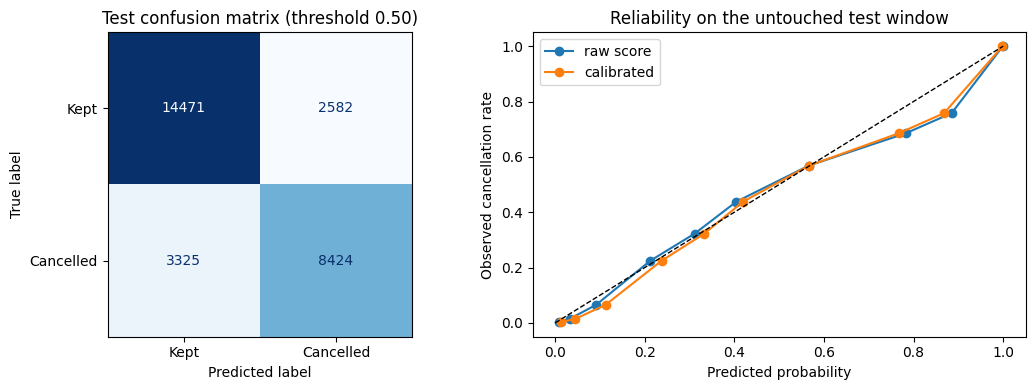

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=["Kept", "Cancelled"]).plot(ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title(f"Test confusion matrix (threshold {DECISION_THRESHOLD:.2f})")
for name, p in [("raw score", test_raw), ("calibrated", test_proba)]:
    fr, mp = calibration_curve(y_test, p, n_bins=10, strategy="quantile"); ax[1].plot(mp, fr, marker="o", label=name)
ax[1].plot([0, 1], [0, 1], "k--", lw=1); ax[1].set_xlabel("Predicted probability"); ax[1].set_ylabel("Observed cancellation rate")
ax[1].set_title("Reliability on the untouched test window"); ax[1].legend(); plt.tight_layout(); plt.show()

The test window (Mar-Aug 2017) behaves differently from the training window (40.8 % cancelled vs 35.9 %), and the calibrated scores over-shoot slightly there (mean predicted 43.8 % vs 40.8 % observed). That is ordinary drift when forecasting forward in time: calibration should be refreshed periodically once new outcomes are known.

## 10. Explainability — what drives the model?

                     feature  shap_share  gain_share
                     country      0.1596      0.0166
                deposit_type      0.1324      0.5135
                       agent      0.1084      0.0215
   total_of_special_requests      0.1065      0.0400
                   lead_time      0.0724      0.0186
              market_segment      0.0649      0.0956
               sibling_count      0.0595      0.0065
               customer_type      0.0508      0.0356
           arrival_date_year      0.0339      0.0104
           arrival_month_cos      0.0263      0.0063
        agent_day_lead_count      0.0235      0.0038
lead_time_x_special_requests      0.0157      0.0045


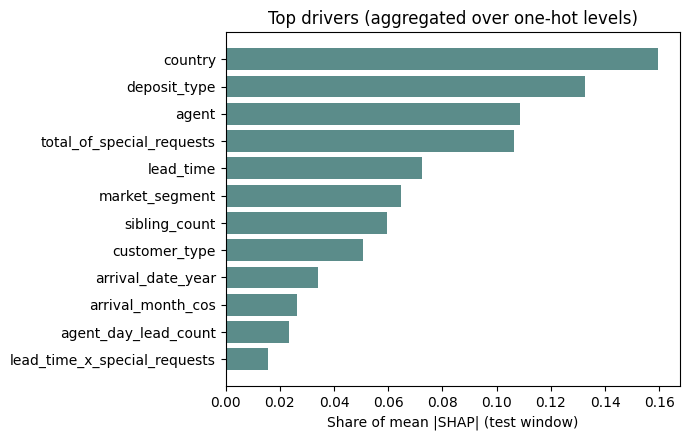

In [27]:
feat_names = pre_full.get_feature_names_out()
def base_name(n):
    n = n.split("__", 1)[1] if "__" in n else n
    for c in CAT:
        if n.startswith(c + "_"): return c
    return n
orig = np.array([base_name(n) for n in feat_names])

booster = final_model.get_booster()
import xgboost as xgb
contrib = booster.predict(xgb.DMatrix(Xte, feature_names=list(feat_names)), pred_contribs=True)[:, :-1]     # TreeSHAP, log-odds units
shap_level = pd.Series(np.abs(contrib).mean(0), index=feat_names)
shap_feature = shap_level.groupby(orig).sum().sort_values(ascending=False)
gain_level = pd.Series(final_model.feature_importances_, index=feat_names)
gain_feature = gain_level.groupby(orig).sum().sort_values(ascending=False)

imp = pd.DataFrame({"feature": shap_feature.index, "shap_share": (shap_feature / shap_feature.sum()).values})
imp["gain_share"] = imp["feature"].map(gain_feature / gain_feature.sum())
imp = imp.round(4); print(imp.head(12).to_string(index=False))

top = shap_feature.head(12)[::-1]
plt.figure(figsize=(7, 4.5)); plt.barh(top.index, top.values / shap_feature.sum(), color="#5b8c8a"); plt.xlabel("Share of mean |SHAP| (test window)")
plt.title("Top drivers (aggregated over one-hot levels)"); plt.tight_layout(); plt.show()

Importance says *how much* a feature is used, not *in which direction*. Direction and size of effect are shown by observed cancellation rates below (and by the what-if scoring in the chatbot).

In [28]:
for col in ["deposit_type", "market_segment", "lead_time_category", "customer_type"]:
    t = ml_df.groupby(col)[TARGET].agg(rate="mean", bookings="size").sort_values("rate", ascending=False)
    t["rate"] = (t["rate"] * 100).round(1); print(f"\n{col}\n", t.to_string())
nr = ml_df[ml_df.deposit_type == "Non Refund"]
print("\nNon Refund bookings: %d, cancellation rate %.1f%%, share from Portugal: %.1f%%" % (len(nr), nr[TARGET].mean() * 100, (nr.country == "PRT").mean() * 100))


deposit_type
               rate  bookings
deposit_type                
Non Refund    99.4     14587
No Deposit    28.4    104640
Refundable    22.2       162

market_segment
                  rate  bookings
market_segment                 
Unknown         100.0         2
Groups           61.1     19810
Online TA        36.7     56477
Offline TA/TO    34.3     24219
Aviation         21.9       237
Corporate        18.7      5295
Direct           15.3     12606
Complementary    13.1       743

lead_time_category
                     rate  bookings
lead_time_category                
Very Long Term      57.0     24691
Long Term           44.7     26439
Medium Term         37.7     29553
Short Term          27.9     18960
Last Minute          9.6     19746

customer_type
                  rate  bookings
customer_type                  
Transient        40.7     89613
Contract         31.0      4076
Transient-Party  25.4     25123
Group            10.2       577

Non Refund bookings: 14587, 

> ⚠️ **Data caveat.** In this dataset “Non Refund” bookings are cancelled ~99 % of the time and almost all of them come from Portugal. That is the opposite of what a non-refundable rate is meant to do and is a well-known quirk of the source data (probably how the hotel's system recorded those bookings), not a business rule. The model uses it because it is genuinely predictive **in this data**, but it should not be read as advice to “sell more non-refundable rates”.

## 11. Save the deployable artefacts

In [29]:
joblib.dump(pre_full, OUT_DIR / "preprocessor.joblib")
joblib.dump(final_model, OUT_DIR / "best_model.joblib")
# native, version-proof format when the winning model supports one; joblib is always saved too
NATIVE_MODEL_FILE = None
if FINAL_MODEL_NAME.startswith("XGBoost"):
    final_model.get_booster().save_model(str(OUT_DIR / "best_model.json")); NATIVE_MODEL_FILE = "best_model.json"
elif FINAL_MODEL_NAME.startswith("CatBoost"):
    final_model.save_model(str(OUT_DIR / "best_model.cbm")); NATIVE_MODEL_FILE = "best_model.cbm"

metadata = {
    "best_model_name": FINAL_MODEL_NAME + " (imbalance-aware, temporal-CV, calibrated)",
    "model_comparison_temporal_cv": comparison_df.to_dict(orient="records"),
    "is_stacking": False, "selection_metric": SELECTION_METRIC,
    "decision_threshold": DECISION_THRESHOLD,
    "calibration": {"method": "platt", "a": platt_a, "b": platt_b, "formula": "p_cal = sigmoid(a * logit(p_raw) + b)"},
    "risk_levels": {"low_below": 0.25, "high_from": DECISION_THRESHOLD},
    "hyperparameters": winner_params,
    "validation": "expanding-window temporal CV inside train_df, windows: " + "; ".join(f"{a}..{b}" for a, b in FOLD_WINDOWS),
    "train_temporal_cv_metrics": {k: float(v) for k, v in metric_row(y_oof, cal_oof, DECISION_THRESHOLD).items()},
    "test_metrics": {k: float(v) for k, v in test_results.items()},
    "train_period": [str(train_df.arrival_date.min().date()), str(train_df.arrival_date.max().date())],
    "test_period": [str(test_df.arrival_date.min().date()), str(test_df.arrival_date.max().date())],
    "excluded_leakage_features": LEAKAGE_COLS,
    "feature_columns_in": X_cols, "high_cardinality_frequency_encoded": HIGH_CARD,
    "preprocessor_file": "preprocessor.joblib", "model_file": "best_model.joblib", "native_model_file": NATIVE_MODEL_FILE,
    "requires": {"python_module": "hotel_utils.py", "scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__, "pandas": pd.__version__},
}
(OUT_DIR / "best_model_metadata.json").write_text(json.dumps(metadata, indent=2))
imp.to_csv(OUT_DIR / "feature_importance.csv", index=False)

# smoke test: reload from disk and reproduce the test predictions exactly
pre_r = joblib.load(OUT_DIR / "preprocessor.joblib"); mdl_r = joblib.load(OUT_DIR / "best_model.joblib")
p_r = calibrate(mdl_r.predict_proba(pre_r.transform(X_test))[:, 1])
print("Reload check -> max |difference| vs in-memory predictions:", float(np.abs(p_r - test_proba).max()))
print("Saved:", sorted(p.name for p in OUT_DIR.iterdir()))

Reload check -> max |difference| vs in-memory predictions: 0.0
Saved: ['best_model.joblib', 'best_model.json', 'best_model_metadata.json', 'feature_importance.csv', 'preprocessor.joblib']


## 12. Scores for the dashboard (out-of-sample for every booking)

A model that has seen a booking scores it too confidently. So each booking's risk is produced by a model that **never saw its calendar month** (8-fold grouped CV over arrival months), then calibrated with the same Platt parameters. Because this is a different procedure from the temporal validation, these scores get their own Platt calibration. The files written here feed the Power BI report and the chatbot.

In [30]:
all_df = ml_df.reset_index(drop=True).copy()
groups = all_df["arrival_date"].dt.to_period("M").astype(str)
Xall = all_df[X_cols]; yall = all_df[TARGET].values
blocked = np.zeros(len(all_df))
for k, (a, b) in enumerate(GroupKFold(n_splits=8).split(Xall, yall, groups), 1):
    pre = make_preprocessor().fit(Xall.iloc[a])
    m = winner_factory(**winner_params)()
    m.fit(pre.transform(Xall.iloc[a]), yall[a], sample_weight=recency_weights(all_df["arrival_date"].iloc[a]))
    blocked[b] = m.predict_proba(pre.transform(Xall.iloc[b]))[:, 1]
# These scores come from a different procedure (8 month-blocked folds, all other months in training) than the temporal
# validation the first Platt fit was made on, so they get their own one-parameter calibration.
platt_blk = LogisticRegression(C=1e6).fit(logit(blocked).reshape(-1, 1), yall)
a_blk, b_blk = float(platt_blk.coef_[0, 0]), float(platt_blk.intercept_[0])
all_df["risk_prob"] = 1 / (1 + np.exp(-(a_blk * logit(blocked) + b_blk)))
print("Blocked-by-month calibration: p = sigmoid(%.4f * logit(p) + %.4f)" % (a_blk, b_blk))
print("Blocked-by-month out-of-sample check on ALL bookings: Accuracy %.4f | ROC-AUC %.4f | mean risk %.3f vs actual %.3f" % (
    accuracy_score(yall, all_df.risk_prob >= DECISION_THRESHOLD), roc_auc_score(yall, all_df.risk_prob), all_df.risk_prob.mean(), yall.mean()))

Blocked-by-month calibration: p = sigmoid(1.0632 * logit(p) + -0.5430)
Blocked-by-month out-of-sample check on ALL bookings: Accuracy 0.8445 | ROC-AUC 0.9239 | mean risk 0.370 vs actual 0.370


In [31]:
LOW, HIGH = 0.25, DECISION_THRESHOLD
raw = data.reset_index(drop=True)                        # original (un-collapsed) columns for reporting
scored = pd.DataFrame({
    "booking_id": np.arange(1, len(raw) + 1), "hotel": raw["hotel"], "arrival_date": all_df["arrival_date"].dt.date,
    "arrival_year": raw["arrival_date_year"], "arrival_month": raw["arrival_date_month"],
    "lead_time": raw["lead_time"], "lead_time_category": raw["lead_time_category"],
    "market_segment": raw["market_segment"], "deposit_type": raw["deposit_type"], "customer_type": raw["customer_type"],
    "country": raw["country"], "agent": raw["agent"], "adr": raw["adr"], "total_nights": raw["total_nights"],
    "previous_cancellations": raw["previous_cancellations"], "total_of_special_requests": raw["total_of_special_requests"],
    "days_in_waiting_list": raw["days_in_waiting_list"], "is_repeated_guest": raw["is_repeated_guest"],
    "estimated_revenue": raw["estimated_revenue"], "is_canceled": raw[TARGET],
    "risk_prob": all_df["risk_prob"].round(4),
})
scored["risk_level"] = pd.cut(scored["risk_prob"], [-1, LOW, HIGH, 2], labels=["Low", "Medium", "High"], right=False).astype(str)
scored["predicted_cancel"] = (scored["risk_prob"] >= HIGH).astype(int)
scored["expected_lost_revenue"] = (scored["risk_prob"] * scored["estimated_revenue"]).round(2)
scored["expected_realised_revenue"] = ((1 - scored["risk_prob"]) * scored["estimated_revenue"]).round(2)
scored.to_csv(OUT_DIR / "bookings_scored.csv", index=False)

# Waiting list: bookings that waited > 0 days. Guests are ranked by expected realised revenue (a safe, valuable guest first);
# zero-night / zero-ADR rows (complimentary or invalid stays) carry no revenue and are excluded from the priority ranking.
wl = scored[(scored.days_in_waiting_list > 0) & (scored.total_nights > 0) & (scored.adr > 0)].copy()
wl["priority_rank"] = wl["expected_realised_revenue"].rank(ascending=False, method="first").astype(int)
wl = wl.sort_values("priority_rank")[["priority_rank", "booking_id", "hotel", "arrival_date", "total_nights", "days_in_waiting_list", "adr",
                                      "risk_prob", "risk_level", "estimated_revenue", "expected_realised_revenue"]]
wl.to_csv(OUT_DIR / "waiting_list_priority.csv", index=False)

kpi = {
    "total_bookings": int(len(scored)), "cancellation_rate": float(scored.is_canceled.mean()),
    "booked_revenue_all": float(scored.estimated_revenue.sum()), "realised_revenue": float(scored.loc[scored.is_canceled == 0, "estimated_revenue"].sum()),
    "lost_revenue_actual": float(scored.loc[scored.is_canceled == 1, "estimated_revenue"].sum()),
    "expected_lost_revenue_model": float(scored.expected_lost_revenue.sum()), "avg_adr": float(scored.adr.mean()),
    "high_risk_bookings": int((scored.risk_level == "High").sum()), "high_risk_share": float((scored.risk_level == "High").mean()),
    "repeat_guest_rate": float(scored.is_repeated_guest.mean()), "waiting_list_size": int((scored.days_in_waiting_list > 0).sum()),
    "waiting_list_avg_risk": float(scored.loc[scored.days_in_waiting_list > 0, "risk_prob"].mean()),
}
(OUT_DIR / "dashboard_kpis.json").write_text(json.dumps(kpi, indent=2))
print(json.dumps({k: (round(v, 4) if isinstance(v, float) else v) for k, v in kpi.items()}, indent=1))
print("\nRisk levels:\n", scored.groupby("risk_level").agg(bookings=("risk_prob", "size"), avg_risk=("risk_prob", "mean"), actual_cancel_rate=("is_canceled", "mean")).round(3))

{
 "total_bookings": 119389,
 "cancellation_rate": 0.3704,
 "booked_revenue_all": 42723561.33,
 "realised_revenue": 25996324.21,
 "lost_revenue_actual": 16727237.12,
 "expected_lost_revenue_model": 16812400.75,
 "avg_adr": 101.832,
 "high_risk_bookings": 40453,
 "high_risk_share": 0.3388,
 "repeat_guest_rate": 0.0319,
 "waiting_list_size": 3698,
 "waiting_list_avg_risk": 0.6674
}

Risk levels:
             bookings  avg_risk  actual_cancel_rate
risk_level                                        
High           40453     0.820               0.817
Low            59050     0.066               0.064
Medium         19886     0.359               0.370


## 13. Final summary

In [32]:
summary = pd.DataFrame([
    {"Model": "Dummy baseline", "Stage": "Temporal CV (train)", **baseline_results},
    {"Model": "XGBoost previous params", "Stage": "Temporal CV (train)",
     **metric_row(y_oof, search_oof[0][mask_oof], best_threshold(y_oof, search_oof[0][mask_oof])[0])},
    {"Model": "XGBoost (tuned)", "Stage": "Temporal CV (train)",
     **metric_row(y_oof, xgb_oof[mask_oof], best_threshold(y_oof, xgb_oof[mask_oof])[0])},
    {"Model": "LightGBM (tuned)", "Stage": "Temporal CV (train)",
     **metric_row(y_oof, lgbm_oof[mask_oof], best_threshold(y_oof, lgbm_oof[mask_oof])[0])},
    {"Model": "Random Forest (tuned)", "Stage": "Temporal CV (train)",
     **metric_row(y_oof, rf_oof[mask_oof], best_threshold(y_oof, rf_oof[mask_oof])[0])},
    {"Model": "CatBoost (tuned)", "Stage": "Temporal CV (train)",
     **metric_row(y_oof, cat_oof[mask_oof], best_threshold(y_oof, cat_oof[mask_oof])[0])},
    {"Model": "Logistic Regression (tuned)", "Stage": "Temporal CV (train)",
     **metric_row(y_oof, logreg_oof[mask_oof], best_threshold(y_oof, logreg_oof[mask_oof])[0])},
    {"Model": "Blend XGB+LGBM", "Stage": "Temporal CV (train)",
     **metric_row(y_oof, blend_oof[mask_oof], best_threshold(y_oof, blend_oof[mask_oof])[0])},
    {"Model": f"{FINAL_MODEL_NAME} (calibrated, WINNER)", "Stage": "Temporal CV (train), calibrated",
     **metric_row(y_oof, cal_oof, DECISION_THRESHOLD)},
    {"Model": f"{FINAL_MODEL_NAME} — FINAL", "Stage": "Test (one-time)", **test_results},
]).round(4)
summary

,Model,Stage,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Dummy baseline,Temporal CV (train),0.6363,0.0000,0.0000,0.0000,0.4821,0.3531
1,XGBoost previous params,Temporal CV (train),0.8270,0.7971,0.7034,0.7473,0.9015,0.8594
2,XGBoost (tuned),Temporal CV (train),0.8305,0.8044,0.7056,0.7518,0.9037,0.8628
3,LightGBM (tuned),Temporal CV (train),0.8262,0.7795,0.7282,0.7530,0.8982,0.8576
4,Random Forest (tuned),Temporal CV (train),0.8289,0.7809,0.7363,0.7579,0.8958,0.8528
5,CatBoost (tuned),Temporal CV (train),0.8294,0.7950,0.7156,0.7532,0.9007,0.8609
6,Logistic Regression (tuned),Temporal CV (train),0.8005,0.7241,0.7294,0.7267,0.8688,0.8180
7,Blend XGB+LGBM,Temporal CV (train),0.8305,0.8027,0.7081,0.7525,0.9036,0.8629
8,"XGBoost (tuned) (calibrated, WINNER)","Temporal CV (train), calibrated",0.8307,0.8057,0.7044,0.7516,0.9037,0.8628
9,XGBoost (tuned) — FINAL,Test (one-time),0.7949,0.7654,0.7170,0.7404,0.8847,0.8459
